# Q13
This question should be answered using the Weekly data set, which is part of the ISLP package. This data is similar in nature to the Smarket data from this chapter’s lab, except that it contains 1,089 weekly returns for 21 years, from the beginning of 1990 to the end of 2010.

In [11]:
# packages
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize)
from ISLP.models import contrast
from ISLP import confusion_table
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis as LDA, QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [24]:
df = load_data('Weekly')
df

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up
...,...,...,...,...,...,...,...,...,...
1084,2010,-0.861,0.043,-2.173,3.599,0.015,3.205160,2.969,Up
1085,2010,2.969,-0.861,0.043,-2.173,3.599,4.242568,1.281,Up
1086,2010,1.281,2.969,-0.861,0.043,-2.173,4.835082,0.283,Up
1087,2010,0.283,1.281,2.969,-0.861,0.043,4.454044,1.034,Up


**Column Description**  
Lag1–Lag5: The returns rate from the previous 1 to 5 days.  
Volume: The trading volume of the current day.  
Today: The return rate of the current day.  
Direction: The market direction for the current day whether it went up or down.  

### (a)  
Produce some numerical and graphical summaries of the Weekly data. Do there appear to be any patterns?

In [28]:
pd.set_option('display.float_format', '{:.3f}'.format)
df.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1089.000,1089.000,1089.000,1089.000,1089.000,1089.000,1089.000,1089.000
mean,2000.049,0.151,0.151,0.147,0.146,0.140,1.575,0.150
std,6.033,2.357,2.357,2.361,2.360,2.361,1.687,2.357
min,1990.000,-18.195,-18.195,-18.195,-18.195,-18.195,0.087,-18.195
25%,1995.000,-1.154,-1.154,-1.158,-1.158,-1.166,0.332,-1.154
50%,2000.000,0.241,0.241,0.241,0.238,0.234,1.003,0.241
75%,2005.000,1.405,1.409,1.409,1.409,1.405,2.054,1.405
max,2010.000,12.026,12.026,12.026,12.026,12.026,9.328,12.026


array([[<Axes: xlabel='Year', ylabel='Year'>,
        <Axes: xlabel='Lag1', ylabel='Year'>,
        <Axes: xlabel='Lag2', ylabel='Year'>,
        <Axes: xlabel='Lag3', ylabel='Year'>,
        <Axes: xlabel='Lag4', ylabel='Year'>,
        <Axes: xlabel='Lag5', ylabel='Year'>,
        <Axes: xlabel='Volume', ylabel='Year'>,
        <Axes: xlabel='Today', ylabel='Year'>],
       [<Axes: xlabel='Year', ylabel='Lag1'>,
        <Axes: xlabel='Lag1', ylabel='Lag1'>,
        <Axes: xlabel='Lag2', ylabel='Lag1'>,
        <Axes: xlabel='Lag3', ylabel='Lag1'>,
        <Axes: xlabel='Lag4', ylabel='Lag1'>,
        <Axes: xlabel='Lag5', ylabel='Lag1'>,
        <Axes: xlabel='Volume', ylabel='Lag1'>,
        <Axes: xlabel='Today', ylabel='Lag1'>],
       [<Axes: xlabel='Year', ylabel='Lag2'>,
        <Axes: xlabel='Lag1', ylabel='Lag2'>,
        <Axes: xlabel='Lag2', ylabel='Lag2'>,
        <Axes: xlabel='Lag3', ylabel='Lag2'>,
        <Axes: xlabel='Lag4', ylabel='Lag2'>,
        <Axes: xlabel='Lag

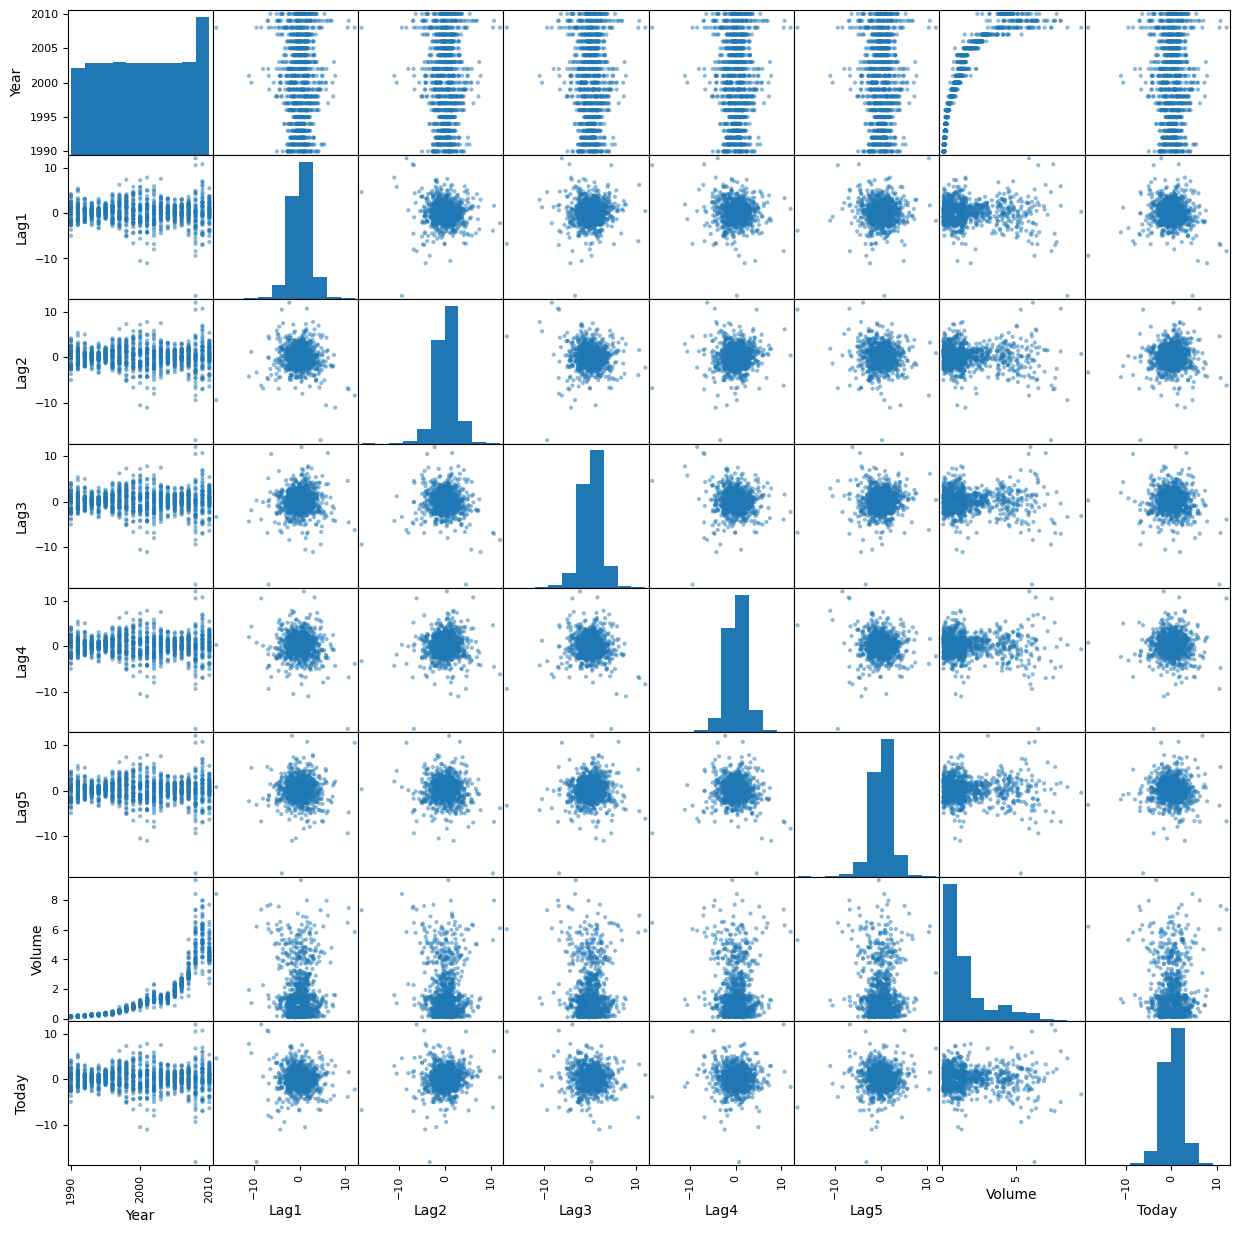

In [29]:
pd.plotting.scatter_matrix(df, figsize=(15,15))


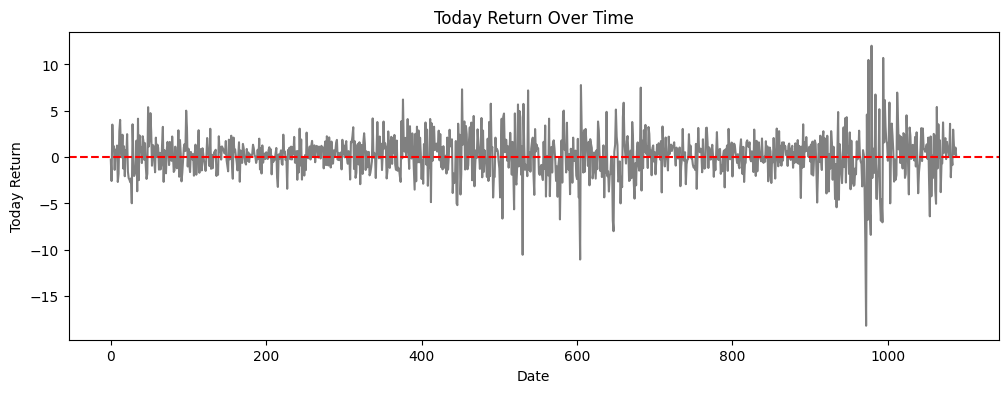

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(df.index, df['Today'], color='gray')
plt.xlabel('Date')
plt.ylabel('Today Return')
plt.title('Today Return Over Time')
plt.axhline(0, color='red', linestyle='--')
plt.show()


### (b)  
Use the full data set to perform a logistic regression with Direction as the response and the five lag variables plus Volume as predictors. Use the summary function to print the results. Do any of the predictors appear to be statistically significant? If so, which ones?

###  (c)  
Compute the confusion matrix and overall fraction of correct predictions. Explain what the confusion matrix is telling you about the types of mistakes made by logistic regression.

### (d)  
Nowfitthe logistic regression model using a training data period from 1990 to 2008, with Lag2 as the only predictor. Compute the confusion matrix and the overall fraction of correct predictions for the held out data (that is, the data from 2009 and 2010).

### (e)  
Repeat (d) using LDA.

### (f)  
Repeat (d) using QDA.

### (g)  
Repeat (d) using KNN with K =1.

### (h)  
Repeat (d) using naive Bayes.

### (i)  
Which of these methods appears to provide the best results on this data?

### (j)  
Experiment with different combinations of predictors, including possible transformations and interactions, for each of the methods. Report the variables, method, and associated confusion matrix that appears to provide the best results on the held out data. Note that you should also experiment with values for K in the KNN classifier.